In [6]:
from ncore.data import (
    FrameTimepoint
)
import ncore.data.v3
import glob
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import json 

import ncore.impl.common.common as ncore_common
import ncore.impl.common.transformations as ncore_transformations
from ncore.impl.data.types import FrameTimepoint, RowOffsetStructuredSpinningLidarModelParameters
from ncore.impl.sensors.lidar import LidarModel
from ncore.impl.data.data3 import ShardDataLoader, ContainerDataWriter

from typing import Union, Optional
from scipy.interpolate import interp1d
from pathlib import Path

import torch
import numpy as np
import open3d as o3d
import tqdm

def undo_motion_compensation(
    xyz: np.ndarray, poses_start_end: np.ndarray, timestamps_startend_us: list, timestamp_us: np.ndarray
) -> np.ndarray:
    """
    undo motion-compensation to bring ray's into time-dependent sensor-frame

    Args:
        xyz (np.array): points from the sensor space [n,3]
        T_sensor_end_sensor_start (np.array): relative pose from end-of-frame to start-of-frame in sensor space [4,4]
        timestamps_startend_us (list): contains [start timestamp, end timestamp]
        timestamp_us (np.array): recoding target per-point timestamps [n]
    Out:
        (np.array): points after undo motion-compensation[n,3]
    """

    pose_interpolator = ncore_common.PoseInterpolator(
        poses_start_end,
        timestamps_startend_us,
    )

    # Note: this interpolation will fail if the point's timestamps are outside of the frame's start/end times - issue dedicated error in that case
    assert (
        (timestamps_startend_us[0] <= timestamp_us).all() and (timestamp_us <= timestamps_startend_us[1]).all()
    ), f"{undo_motion_compensation}: Lidar point timestamps out of frame timestamp bounds - this is an inconsistency in the dataset's internal data and needs to be fixed at dataset creation time"
    T_sensor_end_sensor_pointtime = pose_interpolator.interpolate_to_timestamps(timestamp_us)

    xyz = ncore_transformations.transform_point_cloud(xyz[:, np.newaxis, :], T_sensor_end_sensor_pointtime).squeeze(1)

    return xyz

def to_torch(
    var: Union[torch.Tensor, np.ndarray],
    device: Union[str, torch.device],
    dtype: Optional[torch.dtype] = None,
) -> torch.Tensor:
    """Converts an input array / tensor to a tensor on the target device (with optional dtype conversion)."""
    if isinstance(var, np.ndarray):
        # Torch doesn't support uint32 and uint64 so we cast them to signed integers beforehand
        # Note that this can cause problems

        if var.dtype == np.uint16:
            assert np.all(var <= np.iinfo(np.int16).max), (
                "[CameraModel]: Trying to cast uint16 to int16 but the value exceeds max range."
            )
            var = var.astype(np.int16)

        if var.dtype == np.uint32:
            assert np.all(var <= np.iinfo(np.int32).max), (
                "[CameraModel]: Trying to cast uint32 to int32 but the value exceeds max range."
            )
            var = var.astype(np.int32)

        if var.dtype == np.uint64:
            assert np.all(var <= np.iinfo(np.int64).max), (
                "[CameraModel]: Trying to cast uint64 to int64 but the value exceeds max range."
            )
            var = var.astype(np.int64)

        var = torch.from_numpy(var)

    return var.to(device=device, dtype=dtype)

def sensor_rays_to_sensor_angles(sensor_rays):
    """Computes the elevation and azimuth angles for normalized 3d sensor rays."""

    # sensor_rays: N x 3 array of sensor rays
    assert sensor_rays.ndim == 2

    sensor_rays = to_torch(sensor_rays, 'cpu')

    sensor_rays /= torch.norm(sensor_rays, dim=-1, keepdim=True)

    elevations_rad = torch.asin(sensor_rays[:, 2])
    azimuths_rad = torch.atan2(sensor_rays[:, 1], sensor_rays[:, 0])

    return azimuths_rad, elevations_rad

def compute_median_elevation_per_ring(all_elevations, all_ring_ids):
    """Fast vectorized computation of median elevation per ring"""
    
    # Sort by ring_id for efficient grouping
    sort_indices = np.argsort(all_ring_ids)
    sorted_ring_ids = all_ring_ids[sort_indices]
    sorted_elevations = all_elevations[sort_indices]
    
    # Find unique ring IDs and their boundaries
    unique_ring_ids, inverse_indices, counts = np.unique(sorted_ring_ids, return_inverse=True, return_counts=True)
    
    # Compute median for each group
    median_elevations = []
    std_elevations = []
    start_idx = 0
    
    for count in counts:
        end_idx = start_idx + count
        group_elevations = sorted_elevations[start_idx:end_idx]
        median_elevations.append(np.median(group_elevations))
        std_elevations.append(np.std(group_elevations))
        start_idx = end_idx
    
    return unique_ring_ids, np.array(median_elevations), np.array(std_elevations)

def compute_median_azimuth_per_ring(all_azimuths, all_ring_ids, row_azimuth_offsets_rad):
    
    # Sort by ring_id for efficient grouping
    sort_indices = np.argsort(all_ring_ids)
    sorted_ring_ids = all_ring_ids[sort_indices]
    sorted_azimuths = all_azimuths[sort_indices]
    
    # Find unique ring IDs and their boundaries
    unique_ring_ids, inverse_indices, counts = np.unique(sorted_ring_ids, return_inverse=True, return_counts=True)
    
    all_azimuths = []
    start_idx = 0
    for ring_id, count in zip(unique_ring_ids, counts):
        end_idx = start_idx + count
        group_azimuths = sorted_azimuths[start_idx:end_idx]
        group_azimuths -= row_azimuth_offsets_rad[ring_id] # Ring IDs start at 0
        all_azimuths.append(group_azimuths)
        start_idx = end_idx

    return all_azimuths

def interpolate_missing_ring_elevations(unique_ring_ids, median_row_elevations_rad, expected_total_rings=128):
    """
    Interpolate missing ring elevations using linear interpolation.
    
    Parameters:
    -----------
    unique_ring_ids : array-like
        Ring IDs that were found in the data
    median_row_elevations_rad : array-like  
        Measured median elevations for the found rings (in radians)
    expected_total_rings : int
        Total number of rings expected (default 128 for Hesai AT128)
        
    Returns:
    --------
    complete_ring_ids : np.array
        Complete sequence of ring IDs from ring_start to ring_start+expected_total_rings-1
    complete_elevations_rad : np.array
        Elevations for all rings (measured + interpolated)
    interpolated_mask : np.array
        Boolean mask indicating which values were interpolated (True = interpolated)
    """
    
    # Convert to numpy arrays and sort by ring ID
    unique_ring_ids = np.array(unique_ring_ids)
    median_row_elevations_rad = np.array(median_row_elevations_rad)
    
    # Sort by ring ID to ensure proper ordering
    sort_indices = np.argsort(unique_ring_ids)
    sorted_ring_ids = unique_ring_ids[sort_indices]
    sorted_elevations = median_row_elevations_rad[sort_indices]
    
    # Create complete ring ID sequence
    complete_ring_ids = np.arange(expected_total_rings)
    
    # Initialize output arrays
    complete_elevations_rad = np.full(expected_total_rings, np.nan)
    interpolated_mask = np.ones(expected_total_rings, dtype=bool)  # True = interpolated

    complete_elevations_rad[sorted_ring_ids] = sorted_elevations
    interpolated_mask[sorted_ring_ids] = False  # False = measured (not interpolated)
    

    measured_count = np.sum(~interpolated_mask)
    missing_count = np.sum(interpolated_mask)
    
    if measured_count < 2:
        print("Error: Need at least 2 measured rings for interpolation")
        return complete_ring_ids, complete_elevations_rad, interpolated_mask
    
        
    if missing_count == 0:
        return complete_ring_ids, complete_elevations_rad, interpolated_mask

    # Create interpolation function
    measured_rings = sorted_ring_ids
    measured_elevs = sorted_elevations
    
    interp_func = interp1d(measured_rings, measured_elevs, 
                          kind='linear', fill_value='extrapolate')
    
    # Fill missing values
    missing_indices = np.where(interpolated_mask)[0]

    missing_ring_positions = complete_ring_ids[missing_indices]
    interpolated_elevations = interp_func(missing_ring_positions)
    complete_elevations_rad[missing_indices] = interpolated_elevations
        
    return complete_ring_ids, complete_elevations_rad, interpolated_mask

In [7]:
# lidar model estimation for customers using AT128
# load the point clouds
raw_path = "/home/joeyk/data/1718257000686/lidar_umc/"
# raw_path = "/home/joeyk/data/XiaoMi/866034_before_motion/lidar_umc/"
raw_files_path_sorted = sorted(glob.glob(raw_path + "*.ply"))

# Nominal LiDAR model parameters from the manual
n_rows = 128
row_elevations_deg = np.linspace(12.93, -12.47, 128, endpoint=True)
column_azimuths_deg = np.linspace(60, -60, 1200, endpoint=False)
row_azimuth_offsets_deg = np.tile(np.array([2.4, -0.65]), 64)
row_azimuth_offsets_deg[16:32] *= -1
row_azimuth_offsets_deg[48:64] *= -1
row_azimuth_offsets_deg[80:96] *= -1
row_azimuth_offsets_deg[112:128] *= -1

# Flip the azimuth offsets to match the NCore model which assumes that horizontal_angle = column_azimuth + row_azimuth_offset (as it the case for the HESAI P128, but A128 is the opposite)
row_azimuth_offsets_deg = -row_azimuth_offsets_deg

row_elevations_rad = np.deg2rad(row_elevations_deg)
column_azimuths_rad = np.deg2rad(column_azimuths_deg)
row_azimuth_offsets_rad = np.deg2rad(row_azimuth_offsets_deg)

all_elevations = []
all_azimuths = []
all_ring_ids = []
all_frame_indices = []

for current_frame_idx in range(len(raw_files_path_sorted)):
    pcd = o3d.t.io.read_point_cloud(raw_files_path_sorted[current_frame_idx])
    xyz_e_umc = pcd.point.positions.numpy()
    ring_ids = pcd.point.rings.numpy()

    azimuths_rad, elevations_rad = sensor_rays_to_sensor_angles(xyz_e_umc)
    all_elevations.append(elevations_rad)
    all_azimuths.append(azimuths_rad)
    all_ring_ids.append(ring_ids)
    all_frame_indices.append(current_frame_idx * np.ones_like(ring_ids))

all_elevations = np.concatenate(all_elevations)
all_azimuths = np.concatenate(all_azimuths)
all_ring_ids = np.concatenate(all_ring_ids)
all_frame_indices = np.concatenate(all_frame_indices)

# HERE WE MAKE TWO ASSUMPTIONS:
# 1) The sequence contains at least one point from each of the 128 rings in at least one of the frames (this is not the case for the Xiaomi sequence - see the interpolation method there for a general solution)
# 2) We assume that the across the frames we get at least one measurement from the first and one from the last column.

unique_ring_ids, median_row_elevations_rad, std_row_elevations_rad = compute_median_elevation_per_ring(all_elevations.squeeze(), all_ring_ids.squeeze())
all_azimuths_per_ring = compute_median_azimuth_per_ring(all_azimuths.squeeze(), all_ring_ids.squeeze(), row_azimuth_offsets_rad)

# Interpolate missing ring elevations using linear interpolation.
if median_row_elevations_rad.shape[0] < n_rows:
    unique_ring_ids, median_row_elevations_rad, interpolated_mask = interpolate_missing_ring_elevations(unique_ring_ids, median_row_elevations_rad, expected_total_rings=n_rows)

# Analyze the azimuths per ring
min_max_azimuths = []

for ring_id, azimuths in enumerate(all_azimuths_per_ring):
    min_max_azimuths.append((np.min(azimuths), np.max(azimuths)))

# Convert to numpy arrays for easier handling
min_azimuth = np.min(np.degrees(np.array([minmax[0] for minmax in min_max_azimuths])))
max_azimuth = np.max(np.degrees(np.array([minmax[1] for minmax in min_max_azimuths])))

azimuth_spans_deg = max_azimuth - min_azimuth
column_azimuths_rad_1 = np.deg2rad(np.arange(max_azimuth, min_azimuth, -0.1))

lidar_model_dict = {
    "spinning_frequency_hz": 10.0,
    "spinning_direction": "cw",
    "n_rows": 128,
    "n_columns": column_azimuths_rad_1.shape[0],
    "row_elevations_rad": median_row_elevations_rad.tolist(),
    "column_azimuths_rad": column_azimuths_rad_1.tolist(),
    "row_azimuth_offsets_rad": row_azimuth_offsets_rad.tolist()
}

# Write back to file
with open("estimated_model_hesai_at128.json", 'w') as f:
    json.dump(lidar_model_dict, f, indent=4)


In [8]:
# calculate element id
def compute_lidar_model_elements(
    lidar_model_parameters,
    lidar_model,
    lidar_frame_range,
    tqdm_disabled,
    motion_compensation
) -> dict[int, np.ndarray]:
    """
    Compute per frame model element indices based on GT point cloud and LidarModel.

    Args:
        lidar_model_parameters (ConcreteLidarModelParametersUnion): The lidar model parameters, such as the row elevations
        lidar_frame_range (range): The frame range for which to compute the model parameters
        tqdm_disabled (bool): When True, will not show progress bars

    Returns:
        lidar_model_elements (dict[int, np.ndarray]): Returns the per-frame lidar model elements
    """

    lidar_model_elements: dict[int, np.ndarray] = {}
    lidar_sensor_angles: dict[int, np.ndarray] = {}
    fov = lidar_model_parameters.get_horizontal_fov()
    map_resolution_horiz_rad = fov.span_rad / (lidar_model_parameters.n_columns - 1)

    # Iterate through each frame in lidar_frame_ranges
    for lidar_frame_index in tqdm.tqdm(lidar_frame_range, desc="Nominal Lidar Elements", disable=tqdm_disabled):
        # load ring id from raw data
        pcd = o3d.t.io.read_point_cloud(raw_files_path_sorted[lidar_frame_index])
        ring_ids = pcd.point.rings.numpy().squeeze()
        # Get the ground truth point cloud for the current frame
        pc_lidar_gt = pcd.point.positions.numpy()

        pc_lidar_gt = pc_lidar_gt / np.linalg.norm(pc_lidar_gt, axis=-1, keepdims=True)
        angles = lidar_model.sensor_rays_to_sensor_angles(torch.tensor(pc_lidar_gt, device="cuda")).sensor_angles

        azimuths_offsets_rad = lidar_model_parameters.row_azimuth_offsets_rad[ring_ids]
        azimuths_rad = angles[:, 1] - torch.from_numpy(azimuths_offsets_rad).cuda()
        horizontal_idxs = (
            (
                torch.abs(
                    torch.tensor(lidar_model_parameters.column_azimuths_rad[:, None], device="cuda") - azimuths_rad
                ).argmin(dim=0)
            )
            .to(torch.long)
            .cpu()
            .numpy()
        )
        # vertical_idxs = np.clip(vertical_idxs, 0, lidar_model_parameters.n_rows - 1, out=None)
        horizontal_idxs = np.clip(horizontal_idxs, 0, lidar_model_parameters.n_columns - 1, out=None)
        lidar_model_elements[lidar_frame_index] = np.stack([ring_ids, horizontal_idxs], axis=-1).astype(np.uint16)
        lidar_sensor_angles[lidar_frame_index] = angles

    return lidar_model_elements, lidar_sensor_angles

# load the new lidar model
lidar_model_dict = json.load(open("estimated_model_hesai_at128.json"))
lidar_model_parameters = RowOffsetStructuredSpinningLidarModelParameters.from_dict(lidar_model_dict)
lidar_model = LidarModel.maybe_from_parameters(lidar_model_parameters)

lidar_model_elements, lidar_sensor_angles = compute_lidar_model_elements(lidar_model_parameters=lidar_model_parameters,
                                                    lidar_model=lidar_model,
                                                    lidar_frame_range=range(len(raw_files_path_sorted)),
                                                    tqdm_disabled=False,
                                                    motion_compensation=True
)

Nominal Lidar Elements:   0%|          | 0/142 [00:00<?, ?it/s]

Nominal Lidar Elements: 100%|██████████| 142/142 [00:02<00:00, 70.33it/s]


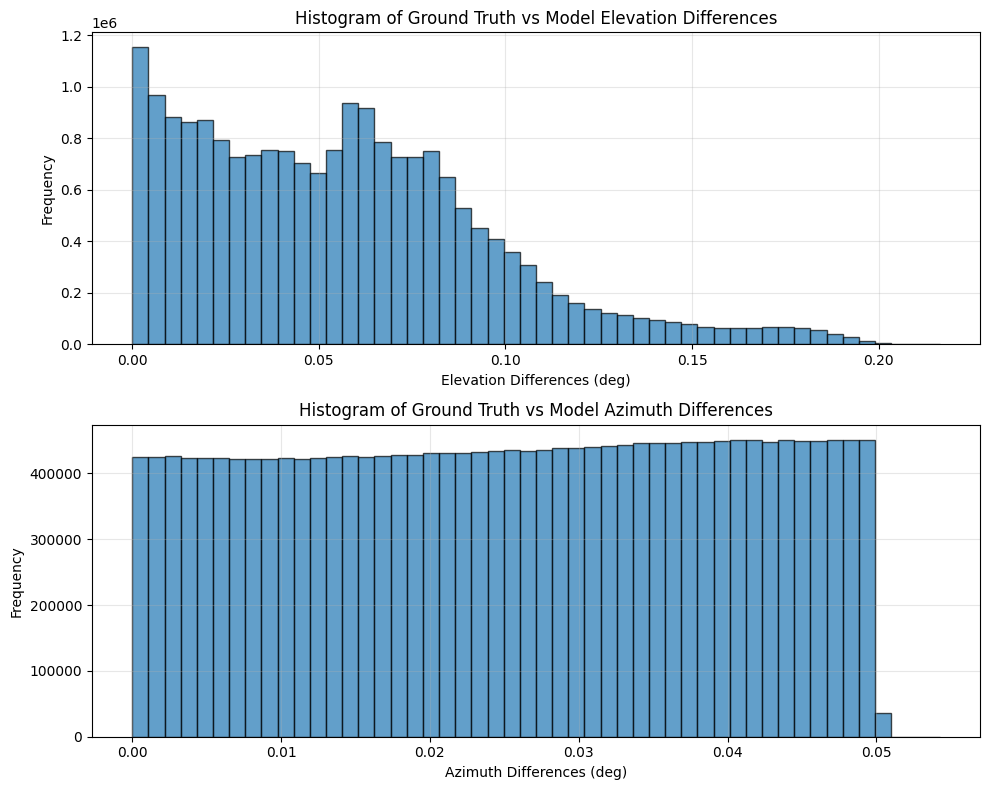

Elevation differences - Mean: 0.056180, Std: 0.039970, Max: 0.216350
Azimuth differences - Mean: 0.025340, Std: 0.014447, Max: 0.054252


In [9]:
# round trip check
gt_sensor_elevations_diffs = []
gt_sensor_azimuths_diffs = []
for frame_index in range(len(raw_files_path_sorted)):
    gt_sensor_angles = lidar_sensor_angles[frame_index].cpu().numpy()
    sensor_angles = lidar_model.elements_to_sensor_angles(lidar_model_elements[frame_index]).cpu().numpy()

    gt_sensor_elevations = gt_sensor_angles[:, 0]
    gt_sensor_azimuths = gt_sensor_angles[:, 1]

    sensor_elevations = sensor_angles[:, 0]
    sensor_azimuths = sensor_angles[:, 1]

    gt_sensor_elevations_diff = np.rad2deg(np.abs(gt_sensor_elevations - sensor_elevations))
    gt_sensor_azimuths_diff = np.rad2deg(np.abs(gt_sensor_azimuths - sensor_azimuths))

    gt_sensor_elevations_diffs.append(gt_sensor_elevations_diff.flatten())
    gt_sensor_azimuths_diffs.append(gt_sensor_azimuths_diff.flatten())

gt_sensor_elevations_diffs = np.concatenate(gt_sensor_elevations_diffs)
gt_sensor_azimuths_diffs = np.concatenate(gt_sensor_azimuths_diffs)

import matplotlib.pyplot as plt

# Create histograms for elevation and azimuth differences
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Histogram for elevation differences
ax1.hist(gt_sensor_elevations_diffs, bins=50, alpha=0.7, edgecolor='black')
ax1.set_xlabel('Elevation Differences (deg)')
ax1.set_ylabel('Frequency')
ax1.set_title('Histogram of Ground Truth vs Model Elevation Differences')
ax1.grid(True, alpha=0.3)

# Histogram for azimuth differences
ax2.hist(gt_sensor_azimuths_diffs.flatten(), bins=50, alpha=0.7, edgecolor='black')
ax2.set_xlabel('Azimuth Differences (deg)')
ax2.set_ylabel('Frequency')
ax2.set_title('Histogram of Ground Truth vs Model Azimuth Differences')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print some statistics
print(f"Elevation differences - Mean: {np.mean(gt_sensor_elevations_diffs):.6f}, "
        f"Std: {np.std(gt_sensor_elevations_diffs):.6f}, "
        f"Max: {np.max(gt_sensor_elevations_diffs):.6f}")
print(f"Azimuth differences - Mean: {np.mean(gt_sensor_azimuths_diffs):.6f}, "
        f"Std: {np.std(gt_sensor_azimuths_diffs):.6f}, "
        f"Max: {np.max(gt_sensor_azimuths_diffs):.6f}")

In [10]:
# write into ncore data
shard_file_pattern = "/home/joeyk/data/1718257000686/ncore/ncore.zarr.itar"
container_name = "ncore_lidar"
output_path_dir = Path("/home/joeyk/data/1718257000686/lidar_elements/")
# shard_file_pattern = "/home/joeyk/data/XiaoMi/866034_before_motion/PILOT-866034/PILOT-866034.zarr.itar"
# container_name = "PILOT-866034_lidar"
# output_path_dir = Path("/home/joeyk/data/XiaoMi/866034_before_motion/PILOT-866034/")

shards = ShardDataLoader.evaluate_shard_file_pattern(shard_file_pattern)
loader = ShardDataLoader(shards)

camera_ids = loader.get_camera_ids()
lidar_ids = loader.get_lidar_ids()

writer = ContainerDataWriter(
        output_dir_path=output_path_dir,
        container_name=container_name,
        camera_ids=camera_ids,
        lidar_ids=lidar_ids,
        radar_ids=[],
        calibration_type=loader._calibration_type,
        egomotion_type=loader._egomotion_type,
        sequence_id=loader._sequence_id,
        generic_meta_data=loader._generic_meta_data,
        shard_id=0,
        shard_count=1,
        store_shard_meta=False,
)

# Resave Pose data
pose_data = loader.get_poses()
writer.store_poses(pose_data)

# Resave Camera data
for camera_id in camera_ids:
    camera_sensor = loader.get_camera_sensor(camera_id)
    camera_sensor_id = camera_sensor.get_sensor_id()
    frame_timestamps_us = camera_sensor.get_frames_timestamps_us()
    T_sensor_rig = camera_sensor.get_T_sensor_rig()
    camera_model_parameters = camera_sensor.get_camera_model_parameters()
    mask_image = camera_sensor.get_camera_mask_image()
    generic_meta_data = camera_sensor.get_generic_meta_data()
    writer.store_camera_meta(camera_id=camera_sensor_id, 
                             frame_timestamps_us=frame_timestamps_us, 
                             T_sensor_rig=T_sensor_rig, 
                             camera_model_parameters=camera_model_parameters, 
                             mask_image=mask_image, 
                             generic_meta_data=generic_meta_data)

    for frame_index in range(len(frame_timestamps_us)):
        frame_data = camera_sensor.get_frame_data(frame_index).get_encoded_image_data()
        T_rig_worlds = np.array([camera_sensor.get_frame_T_rig_world(frame_index, FrameTimepoint.START),
                                 camera_sensor.get_frame_T_rig_world(frame_index, FrameTimepoint.END)])
        timestamps_us = np.array([camera_sensor.get_frame_timestamp_us(frame_index, FrameTimepoint.START),
                                  camera_sensor.get_frame_timestamp_us(frame_index, FrameTimepoint.END)], dtype=np.uint64)
        writer.store_camera_frame(camera_id=camera_sensor_id, 
                                  continuous_frame_index=frame_index, 
                                  image_file_binary_data=frame_data, 
                                  image_file_format="jpeg", 
                                  T_rig_worlds=T_rig_worlds, 
                                  timestamps_us=timestamps_us, 
                                  generic_data={}, 
                                  generic_meta_data={})

# Resave Lidar data
for lidar_id in lidar_ids:
    lidar_sensor = loader.get_lidar_sensor(lidar_id)
    lidar_sensor_id = lidar_sensor.get_sensor_id()
    frame_timestamps_us = lidar_sensor.get_frames_timestamps_us()
    T_sensor_rig = lidar_sensor.get_T_sensor_rig()
    generic_meta_data = lidar_sensor.get_generic_meta_data()
    writer.store_lidar_meta(lidar_id=lidar_sensor_id, 
                            frame_timestamps_us=frame_timestamps_us, 
                            T_sensor_rig=T_sensor_rig, 
                            lidar_model_parameters=lidar_model_parameters, 
                            generic_meta_data=generic_meta_data)

    for frame_index in range(len(frame_timestamps_us)):
        xyz_s = lidar_sensor.get_frame_data(frame_index, "xyz_s")
        xyz_e = lidar_sensor.get_frame_data(frame_index, "xyz_e")
        intensity = lidar_sensor.get_frame_data(frame_index, "intensity")
        timestamp_us = lidar_sensor.get_frame_data(frame_index, "timestamp_us")
        frame_labels = lidar_sensor.get_frame_labels(frame_index)
        # # TODO: You can change the frame labels here:
        # for label in frame_labels:
        #     if label.label_class == "vehicle":
        #         label.bbox3.dim = [1, 1, 1]
        # per frame pose and timestamp
        T_rig_worlds = np.array([lidar_sensor.get_frame_T_rig_world(frame_index, FrameTimepoint.START),
                                 lidar_sensor.get_frame_T_rig_world(frame_index, FrameTimepoint.END)])
        timestamps_us = np.array([lidar_sensor.get_frame_timestamp_us(frame_index, FrameTimepoint.START),
                                  lidar_sensor.get_frame_timestamp_us(frame_index, FrameTimepoint.END)], dtype=np.uint64)
        writer.store_lidar_frame(lidar_id=lidar_sensor_id, 
                                 continuous_frame_index=frame_index, 
                                 xyz_s=xyz_s, 
                                 xyz_e=xyz_e, 
                                 intensity=intensity, 
                                 timestamp_us=timestamp_us, 
                                 model_element=lidar_model_elements[frame_index], 
                                 frame_labels=frame_labels, 
                                 T_rig_worlds=T_rig_worlds, 
                                 timestamps_us=timestamps_us, 
                                 generic_data={}, 
                                 generic_meta_data={})

# Finalize the container
writer.finalize()

PosixPath('/home/joeyk/data/1718257000686/lidar_elements/ncore_lidar.zarr.itar')